In [4]:
import pandas as pd
import numpy as np

In [2]:
DATASET = "../datasets/AMLSimData/0_100"

accounts = pd.read_csv(f'{DATASET}/accounts.csv')
transactions = pd.read_csv(f'{DATASET}/transactions.csv')

In [7]:
matrix = np.zeros((100, 100))

for _, row in transactions.iterrows():
    orig_acct = int(row["SENDER_ACCOUNT_ID"])
    bene_acct = int(row["RECEIVER_ACCOUNT_ID"])
    amount = int(row["TX_AMOUNT"])

    matrix[orig_acct][bene_acct] += amount

In [9]:
matrix_df = pd.DataFrame(matrix)
matrix_df

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1932.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1034.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,738.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,738.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,750.0,0.0,0.0,750.0,0.0,750.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.0,0.0,357.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,357.0,0.0,357.0,357.0,357.0,0.0,0.0,0.0
96,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,408.0,0.0,0.0,0.0,408.0,0.0,0.0,408.0,0.0,0.0
97,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,230.0,230.0,230.0,230.0,230.0,0.0,230.0
98,0.0,0.0,0.0,0.0,0.0,308.0,0.0,0.0,0.0,0.0,...,308.0,0.0,0.0,308.0,308.0,0.0,0.0,308.0,0.0,308.0


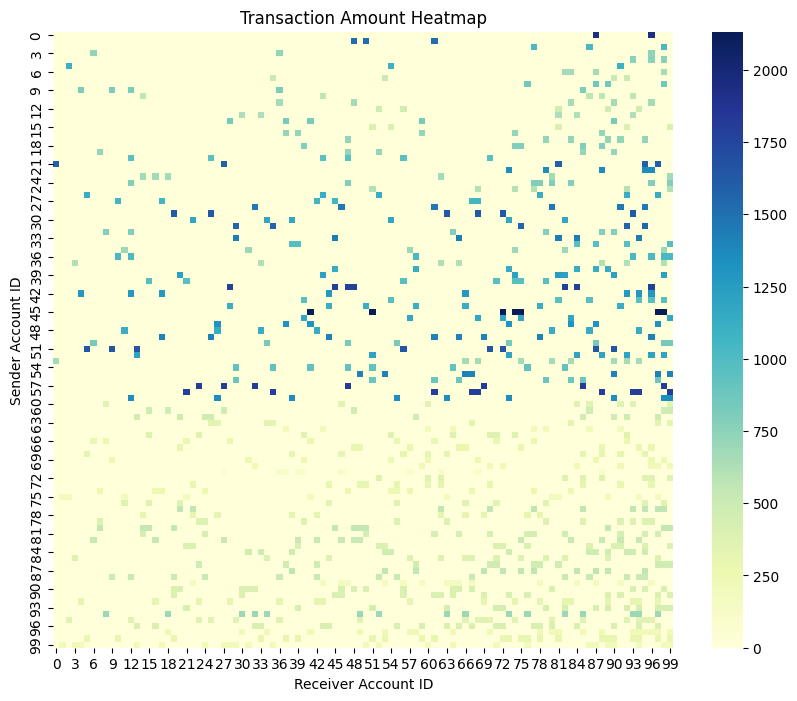

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))  # Adjust size as needed
sns.heatmap(matrix, cmap='YlGnBu', fmt=".2f", cbar=True)

plt.title("Transaction Amount Heatmap")
plt.xlabel("Receiver Account ID")
plt.ylabel("Sender Account ID")
plt.show()


In [13]:
unique_pairs = transactions.groupby(['SENDER_ACCOUNT_ID', 'RECEIVER_ACCOUNT_ID']).size().shape[0]

# Count non-zero cells in the matrix
non_zero_cells = np.count_nonzero(matrix)

if unique_pairs == non_zero_cells:
    print("Matrix correctly populated!")
else:
    print("Discrepancy detected: Matrix may be incorrect.")

Unique sender-receiver pairs: 870
Non-zero cells in matrix: 870
✅ Matrix is correctly populated!
